毒品多分类任务 - 5折交叉验证（按SMILES分组）
80%数据做5折交叉验证，20%独立测试集

设备: cuda
预训练模型: D:\DL\cann\建模\best_model_0725.pt
输出目录: D:\DL\cann\建模\multi_class_cv

1. 加载数据库
  ✓ 芬太尼: 619 个化合物, 561 维
  ✓ 卡西酮: 1082 个化合物, 561 维
  ✓ 大麻素: 1264 个化合物, 561 维
  ✓ Arylcyclohexylamines: 94 个化合物, 561 维
  ✓ Benzodiazepines: 240 个化合物, 561 维
  ✓ Nitazenes: 129 个化合物, 561 维
  ✓ Opiates: 75 个化合物, 561 维
  ✓ Phenethylamines: 152 个化合物, 561 维
  ✓ Tryptamines: 158 个化合物, 561 维

数据库加载摘要

类别                        化合物数         谱图数         
------------------------------------------------------------
芬太尼                       619          619         
卡西酮                       1082         1082        
大麻素                       1264         1264        
Arylcyclohexylamines      94           94          
Benzodiazepines           240          240         
Nitazenes                 129          129         
Opiates                   75           75          
Phenethylamines           152          152         
Tryptamines               158   

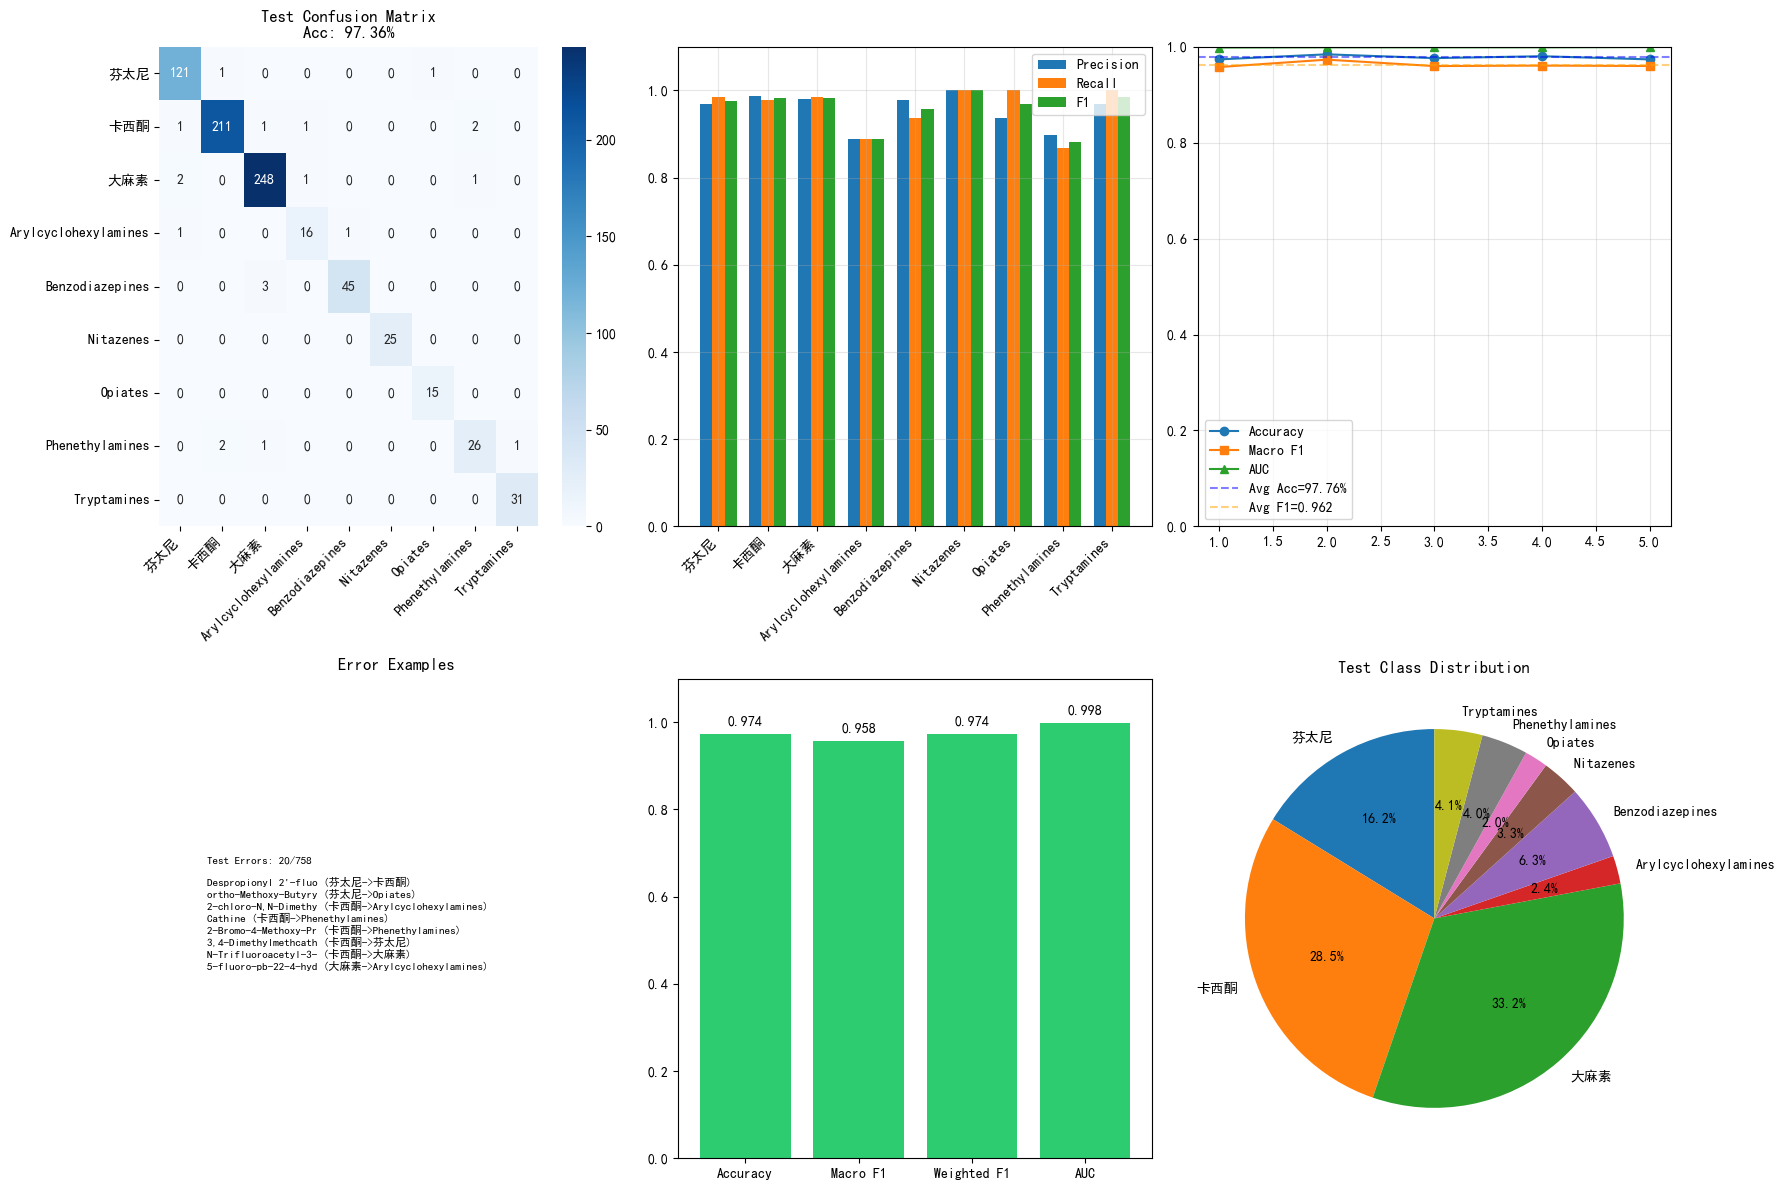

  ✓ 结果汇总Excel已保存: D:\DL\cann\建模\multi_class_cv\test_set_results_20260725_172011.xlsx

12. 保存最佳模型
  最佳Fold: Fold 2
    测试集准确率: 98.42%
    测试集宏平均F1: 0.9731
    测试集AUC: 0.9988
  ✓ 已加载最佳Fold模型权重: D:\DL\cann\建模\multi_class_cv\fold_2_model.pt
  ✓ 最佳模型已保存: D:\DL\cann\建模\multi_class_cv\best_multi_class_model_20260725_172011.pt
  ✓ 轻量模型权重已保存: D:\DL\cann\建模\multi_class_cv\best_multi_class_model_weights_20260725_172011.pt
  ✓ 最新模型已保存: D:\DL\cann\建模\multi_class_cv\best_multi_class_model_latest.pt

完成！
  输出目录: D:\DL\cann\建模\multi_class_cv
  Origin绘图数据目录: D:\DL\cann\建模\multi_class_cv\origin_plot_data_20260725_172007
  最佳模型: D:\DL\cann\建模\multi_class_cv\best_multi_class_model_20260725_172011.pt
  最新模型: D:\DL\cann\建模\multi_class_cv\best_multi_class_model_latest.pt


In [3]:
"""
毒品多分类任务 - 5折交叉验证（按SMILES分组）
修复：评估时使用 shuffle=False 的 DataLoader，确保样本名称与预测一一对应
新增：将所有可视化数据导出为Excel，方便Origin重新绘图
新增：ROC曲线数据导出
新增：保存最佳模型为pt文件
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict, Counter
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import seaborn as sns
import pandas as pd
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("="*60)
print("毒品多分类任务 - 5折交叉验证（按SMILES分组）")
print("80%数据做5折交叉验证，20%独立测试集")
print("="*60)

# ==================== 1. 模型定义 ====================
class SpectrumEncoder(nn.Module):
    def __init__(self, input_dim=561, hidden_dim=256):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Sequential(
            nn.Linear(256, hidden_dim),
            nn.BatchNorm1d(hidden_dim)
        )
    
    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)
        h = self.conv_block(x).squeeze(-1)
        embed = self.fc(h)
        return F.normalize(embed, p=2, dim=1)


class MultiClassClassifier(nn.Module):
    def __init__(self, encoder, num_classes=9, input_dim=256, freeze_encoder=True):
        super().__init__()
        self.encoder = encoder
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x, return_embed=False):
        embed = self.encoder(x)
        logits = self.classifier(embed)
        if return_embed:
            return logits, embed
        return logits


# ==================== 2. 数据解析 ====================
def parse_msp_robust(msp_file, min_peaks=5, min_intensity=10):
    """
    健壮的MSP解析：按条目分割，避免状态残留
    """
    with open(msp_file, 'r', encoding='utf-8') as f:
        content = f.read()
    
    parts = content.split('Name:')
    compounds = []
    
    for part in parts[1:]:
        lines = part.strip().splitlines()
        if not lines:
            continue
        name = lines[0].strip()
        rest = '\n'.join(lines[1:])
        
        smiles = ''
        formula = ''
        mw = 0.0
        peaks = []
        
        # 提取字段
        for line in lines[1:]:
            if line.startswith('SMILES:') or line.startswith('Smiles:'):
                smiles = line.split(':', 1)[1].strip()
            elif line.startswith('Formula:'):
                formula = line.split(':', 1)[1].strip()
            elif line.startswith('MW:'):
                try:
                    mw = float(line.split(':', 1)[1].strip())
                except:
                    mw = 0.0
        
        # 解析峰数据
        idx_num_peaks = rest.find('Num peaks:')
        if idx_num_peaks != -1:
            peak_part = rest[idx_num_peaks:]
            lines_peak = peak_part.splitlines()
            peak_data_str = ' '.join(lines_peak[1:])
            peak_data_str = peak_data_str.replace(';', ' ').replace('\n', ' ')
            tokens = peak_data_str.split()
            for i in range(0, len(tokens)-1, 2):
                try:
                    mz = float(tokens[i])
                    intensity = float(tokens[i+1])
                    if mz > 0 and intensity >= min_intensity:
                        peaks.append((mz, intensity))
                except ValueError:
                    continue
        
        if len(peaks) >= min_peaks:
            compounds.append({
                'name': name,
                'smiles': smiles,
                'formula': formula,
                'mw': mw,
                'peaks': peaks
            })
    
    return compounds


def peaks_to_vector(peaks, mz_min=40, mz_max=600):
    dim = mz_max - mz_min + 1
    vec = np.zeros(dim)
    for mz, intensity in peaks:
        if mz_min <= mz <= mz_max:
            idx = int(round(mz - mz_min))
            if 0 <= idx < dim:
                vec[idx] += intensity
    return vec


def preprocess_spectra(spectra):
    tic = spectra.sum(axis=1, keepdims=True)
    spectra = spectra / (tic + 1e-8)
    spectra = np.sqrt(spectra)
    return spectra


def load_database(database_path, category_name, min_peaks=5, min_intensity=10):
    """加载单个数据库"""
    if not database_path.exists():
        print(f"  ⚠ 文件不存在: {database_path}")
        return None, None
    
    compounds = parse_msp_robust(str(database_path), min_peaks, min_intensity)
    if len(compounds) == 0:
        print(f"  ⚠ 未解析到有效化合物: {database_path}")
        return None, None
    
    spectra = np.array([peaks_to_vector(c['peaks']) for c in compounds])
    spectra = preprocess_spectra(spectra)
    
    print(f"  ✓ {category_name}: {len(compounds)} 个化合物, {spectra.shape[1]} 维")
    return compounds, spectra


# ==================== 3. 分组交叉验证划分 ====================
def stratified_group_kfold(groups, labels, n_splits=5, random_state=42):
    np.random.seed(random_state)
    unique_groups = np.unique(groups)
    group_to_label = {}
    for g in unique_groups:
        mask = groups == g
        group_to_label[g] = labels[mask][0]
    
    label_to_groups = defaultdict(list)
    for g, label in group_to_label.items():
        label_to_groups[label].append(g)
    
    folds = {i: [] for i in range(n_splits)}
    for label, group_list in label_to_groups.items():
        shuffled = group_list.copy()
        np.random.shuffle(shuffled)
        for i, g in enumerate(shuffled):
            fold_idx = i % n_splits
            folds[fold_idx].append(g)
    
    fold_indices = []
    for val_fold in range(n_splits):
        val_groups = folds[val_fold]
        train_groups = []
        for f in range(n_splits):
            if f != val_fold:
                train_groups.extend(folds[f])
        fold_indices.append({
            'train_groups': train_groups,
            'val_groups': val_groups
        })
    return fold_indices


# ==================== 4. 训练函数 ====================
def train_fold(model, train_loader, val_loader, device, num_classes, epochs=1000, lr=0.001, patience=30):
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
    )
    criterion = nn.CrossEntropyLoss()
    
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0
    
    # 记录训练历史
    train_history = []
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for batch_spec, batch_labels in train_loader:
            batch_spec = batch_spec.to(device)
            batch_labels = batch_labels.to(device).long()
            optimizer.zero_grad()
            logits = model(batch_spec)
            loss = criterion(logits, batch_labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * batch_spec.size(0)
            preds = logits.argmax(dim=1)
            train_correct += (preds == batch_labels).sum().item()
            train_total += batch_spec.size(0)
        
        avg_train_loss = train_loss / train_total
        train_acc = train_correct / train_total
        
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for batch_spec, batch_labels in val_loader:
                batch_spec = batch_spec.to(device)
                batch_labels = batch_labels.to(device).long()
                logits = model(batch_spec)
                loss = criterion(logits, batch_labels)
                val_loss += loss.item() * batch_spec.size(0)
                preds = logits.argmax(dim=1)
                val_correct += (preds == batch_labels).sum().item()
                val_total += batch_spec.size(0)
        
        avg_val_loss = val_loss / val_total
        val_acc = val_correct / val_total
        
        train_history.append({
            'epoch': epoch,
            'train_loss': avg_train_loss,
            'train_acc': train_acc,
            'val_loss': avg_val_loss,
            'val_acc': val_acc
        })
        
        scheduler.step(avg_val_loss)
        if epoch % 10 == 0 or epoch == 1:
            print(f'  Epoch {epoch:4d} | Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2%} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2%}')
        
        if avg_val_loss < best_val_loss - 1e-4:
            best_val_loss = avg_val_loss
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f'  早停于 epoch {epoch}')
                break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, train_history


def evaluate_and_record_predictions(model, data_loader, device, class_names, sample_names=None, dataset_name="Test"):
    """
    评估模型并返回每个样本的预测结果
    data_loader 必须 shuffle=False 以确保样本名称顺序一致
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for batch_idx, (batch_spec, batch_labels) in enumerate(data_loader):
            batch_spec = batch_spec.to(device)
            logits = model(batch_spec)
            probs = F.softmax(logits, dim=1)
            preds = logits.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # 如果提供了 sample_names，它们必须与 data_loader 的顺序一致（shuffle=False）
    if sample_names is not None:
        if len(sample_names) != len(all_labels):
            print(f"警告: sample_names 长度 ({len(sample_names)}) 与预测结果长度 ({len(all_labels)}) 不一致")
            sample_names = None
    
    predictions = []
    if sample_names is not None:
        for i in range(len(all_labels)):
            true_label = class_names[all_labels[i]]
            pred_label = class_names[all_preds[i]]
            is_correct = all_labels[i] == all_preds[i]
            true_confidence = all_probs[i][all_labels[i]]
            pred_confidence = all_probs[i][all_preds[i]]
            predictions.append({
                'Name': sample_names[i],
                'True_Label': true_label,
                'Pred_Label': pred_label,
                'True_Index': all_labels[i],
                'Pred_Index': all_preds[i],
                'Is_Correct': is_correct,
                'True_Confidence': true_confidence,
                'Pred_Confidence': pred_confidence,
                'All_Probs': all_probs[i].tolist()
            })
    else:
        for i in range(len(all_labels)):
            predictions.append({
                'Name': f'Sample_{i}',
                'True_Label': class_names[all_labels[i]],
                'Pred_Label': class_names[all_preds[i]],
                'True_Index': all_labels[i],
                'Pred_Index': all_preds[i],
                'Is_Correct': all_labels[i] == all_preds[i],
                'True_Confidence': all_probs[i][all_labels[i]],
                'Pred_Confidence': all_probs[i][all_preds[i]],
                'All_Probs': all_probs[i].tolist()
            })
    
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    try:
        n_classes = len(class_names)
        all_labels_bin = label_binarize(all_labels, classes=range(n_classes))
        auc_ovr = roc_auc_score(all_labels_bin, all_probs, average='macro', multi_class='ovr')
    except:
        auc_ovr = 0.0
    
    per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)
    per_class_prec = precision_score(all_labels, all_preds, average=None, zero_division=0)
    per_class_rec = recall_score(all_labels, all_preds, average=None, zero_division=0)
    cm = confusion_matrix(all_labels, all_preds)
    
    return {
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        'auc_ovr': auc_ovr,
        'per_class_f1': per_class_f1,
        'per_class_precision': per_class_prec,
        'per_class_recall': per_class_rec,
        'confusion_matrix': cm,
        'preds': all_preds,
        'labels': all_labels,
        'probs': all_probs,
        'predictions': predictions,
    }


def print_errors_with_confidence(predictions, class_names, dataset_name="", max_print=50):
    errors = [p for p in predictions if not p['Is_Correct']]
    total = len(predictions)
    if len(errors) == 0:
        print(f"\n  ✅ {dataset_name}: 没有预测错误！")
        return
    print(f"\n  ❌ {dataset_name}: {len(errors)}/{total} 个样本预测错误 ({len(errors)/total:.2%})")
    print(f"  {'='*120}")
    print(f"  {'序号':<6} {'化合物名称':<30} {'真实标签':<18} {'真实置信度':<14} {'预测标签':<18} {'预测置信度':<14} {'Top-2 其他可能类'}")
    print(f"  {'='*120}")
    sorted_errors = sorted(errors, key=lambda x: x['Pred_Confidence'], reverse=True)
    for i, error in enumerate(sorted_errors[:max_print], 1):
        name = error['Name'][:28] + '..' if len(error['Name']) > 30 else error['Name']
        all_probs = error['All_Probs']
        prob_indices = [(idx, prob) for idx, prob in enumerate(all_probs) 
                       if idx != error['True_Index'] and idx != error['Pred_Index']]
        prob_indices.sort(key=lambda x: x[1], reverse=True)
        top2_others = prob_indices[:2]
        top2_str = ""
        for idx, prob in top2_others:
            class_name = class_names[idx] if idx < len(class_names) else f"Class_{idx}"
            top2_str += f"{class_name[:10]}({prob:.3f}) "
        if not top2_str:
            top2_str = "None"
        print(f"  {i:<6} {name:<30} {error['True_Label']:<18} {error['True_Confidence']:.4f}     "
              f"{error['Pred_Label']:<18} {error['Pred_Confidence']:.4f}     {top2_str}")
    if len(errors) > max_print:
        print(f"  ... 还有 {len(errors) - max_print} 个错误未显示")
    print(f"  {'='*120}\n")


def compute_roc_data(all_labels, all_probs, class_names):
    """
    计算每个类别的ROC曲线数据
    返回: 每个类别的fpr, tpr, thresholds, auc
    """
    n_classes = len(class_names)
    all_labels_bin = label_binarize(all_labels, classes=range(n_classes))
    
    roc_data = {}
    for i in range(n_classes):
        fpr, tpr, thresholds = roc_curve(all_labels_bin[:, i], all_probs[:, i])
        roc_auc = auc(fpr, tpr)
        roc_data[class_names[i]] = {
            'fpr': fpr.tolist(),
            'tpr': tpr.tolist(),
            'thresholds': thresholds.tolist(),
            'auc': roc_auc
        }
    
    return roc_data


def export_figure_data_to_excel(output_dir, class_names, fold_results, final_test_results, 
                                test_accs, test_f1s, test_aucs, avg_acc, avg_f1, avg_auc,
                                fold_histories):
    """
    将所有可视化数据导出为独立的Excel文件，方便Origin重新绘图
    """
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    excel_dir = output_dir / f"origin_plot_data_{timestamp}"
    excel_dir.mkdir(exist_ok=True)
    
    print(f"\n正在导出Origin绘图数据到: {excel_dir}")
    
    # ==================== 图1: 混淆矩阵 ====================
    cm = final_test_results['confusion_matrix']
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    cm_df.index.name = 'True\\Pred'
    cm_df.to_excel(excel_dir / 'Fig1_Confusion_Matrix.xlsx')
    print(f"  ✓ Fig1_Confusion_Matrix.xlsx")
    
    # ==================== 图2: 每类指标 (Precision, Recall, F1) ====================
    metrics_df = pd.DataFrame({
        'Class': class_names,
        'Precision': final_test_results['per_class_precision'],
        'Recall': final_test_results['per_class_recall'],
        'F1_Score': final_test_results['per_class_f1'],
        'Support': np.sum(cm, axis=1)
    })
    metrics_df.to_excel(excel_dir / 'Fig2_Per_Class_Metrics.xlsx', index=False)
    print(f"  ✓ Fig2_Per_Class_Metrics.xlsx")
    
    # ==================== 图3: 每折测试结果 ====================
    fold_results_df = pd.DataFrame({
        'Fold': range(1, len(test_accs) + 1),
        'Accuracy': test_accs,
        'Macro_F1': test_f1s,
        'AUC': test_aucs
    })
    fold_results_df.to_excel(excel_dir / 'Fig3_Fold_Results.xlsx', index=False)
    print(f"  ✓ Fig3_Fold_Results.xlsx")
    
    # ==================== 图4: 汇总指标 ====================
    summary_metrics_df = pd.DataFrame({
        'Metric': ['Accuracy', 'Macro_F1', 'Weighted_F1', 'AUC'],
        'Value': [
            final_test_results['accuracy'],
            final_test_results['macro_f1'],
            final_test_results['weighted_f1'],
            final_test_results['auc_ovr']
        ]
    })
    summary_metrics_df.to_excel(excel_dir / 'Fig4_Summary_Metrics.xlsx', index=False)
    print(f"  ✓ Fig4_Summary_Metrics.xlsx")
    
    # ==================== 图5: 类别分布 ====================
    class_dist_df = pd.DataFrame({
        'Class': class_names,
        'Count': np.sum(cm, axis=1),
        'Percentage': np.sum(cm, axis=1) / np.sum(cm) * 100
    })
    class_dist_df.to_excel(excel_dir / 'Fig5_Class_Distribution.xlsx', index=False)
    print(f"  ✓ Fig5_Class_Distribution.xlsx")
    
    # ==================== 图6: 训练曲线 (每个fold) ====================
    if fold_histories:
        for fold_idx, history in enumerate(fold_histories):
            history_df = pd.DataFrame(history)
            history_df.to_excel(excel_dir / f'Fig6_Fold{fold_idx+1}_Training_Curve.xlsx', index=False)
        print(f"  ✓ Fig6_Fold*_Training_Curve.xlsx (共{len(fold_histories)}个fold)")
    
    # ==================== 图7: 所有fold的测试结果对比 ====================
    all_folds_metrics = []
    for i, result in enumerate(fold_results):
        all_folds_metrics.append({
            'Fold': i + 1,
            'Train_Accuracy': result['training']['accuracy'],
            'Val_Accuracy': result['validation']['accuracy'],
            'Test_Accuracy': result['test']['accuracy'],
            'Test_Macro_F1': result['test']['macro_f1'],
            'Test_AUC': result['test']['auc_ovr']
        })
    all_folds_df = pd.DataFrame(all_folds_metrics)
    all_folds_df.to_excel(excel_dir / 'Fig7_All_Folds_Comparison.xlsx', index=False)
    print(f"  ✓ Fig7_All_Folds_Comparison.xlsx")
    
    # ==================== 图8: 混淆矩阵归一化 ====================
    cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    cm_norm_df = pd.DataFrame(cm_normalized, index=class_names, columns=class_names)
    cm_norm_df.index.name = 'True\\Pred'
    cm_norm_df.to_excel(excel_dir / 'Fig8_Confusion_Matrix_Normalized.xlsx')
    print(f"  ✓ Fig8_Confusion_Matrix_Normalized.xlsx")
    
    # ==================== 图9: 错误分析 ====================
    errors = [p for p in final_test_results['predictions'] if not p['Is_Correct']]
    if errors:
        error_df = pd.DataFrame([{
            'Name': p['Name'],
            'True_Label': p['True_Label'],
            'Pred_Label': p['Pred_Label'],
            'True_Confidence': p['True_Confidence'],
            'Pred_Confidence': p['Pred_Confidence']
        } for p in errors])
        error_df.to_excel(excel_dir / 'Fig9_Error_Analysis.xlsx', index=False)
        print(f"  ✓ Fig9_Error_Analysis.xlsx")
    else:
        pd.DataFrame({'Message': ['No errors found']}).to_excel(excel_dir / 'Fig9_Error_Analysis.xlsx', index=False)
        print(f"  ✓ Fig9_Error_Analysis.xlsx (无错误)")
    
    # ==================== 图10: 平均结果 ====================
    avg_results_df = pd.DataFrame({
        'Metric': ['Avg_Accuracy', 'Std_Accuracy', 'Avg_Macro_F1', 'Std_Macro_F1', 'Avg_AUC', 'Std_AUC'],
        'Value': [avg_acc, np.std(test_accs), avg_f1, np.std(test_f1s), avg_auc, np.std(test_aucs)]
    })
    avg_results_df.to_excel(excel_dir / 'Fig10_Average_Results.xlsx', index=False)
    print(f"  ✓ Fig10_Average_Results.xlsx")
    
    # ==================== 图11: 混淆矩阵详细统计 ====================
    cm_detail = []
    for i, true_name in enumerate(class_names):
        for j, pred_name in enumerate(class_names):
            cm_detail.append({
                'True_Class': true_name,
                'Pred_Class': pred_name,
                'Count': cm[i, j],
                'Row_Percentage': cm[i, j] / cm[i, :].sum() * 100 if cm[i, :].sum() > 0 else 0
            })
    cm_detail_df = pd.DataFrame(cm_detail)
    cm_detail_df.to_excel(excel_dir / 'Fig11_Confusion_Matrix_Detail.xlsx', index=False)
    print(f"  ✓ Fig11_Confusion_Matrix_Detail.xlsx")
    
    # ==================== 图12: 每折各类别F1 ====================
    per_fold_per_class_f1 = []
    for i, result in enumerate(fold_results):
        for j, class_name in enumerate(class_names):
            per_fold_per_class_f1.append({
                'Fold': i + 1,
                'Class': class_name,
                'F1_Score': result['test']['per_class_f1'][j] if j < len(result['test']['per_class_f1']) else 0
            })
    per_fold_f1_df = pd.DataFrame(per_fold_per_class_f1)
    per_fold_f1_df.to_excel(excel_dir / 'Fig12_Per_Fold_Per_Class_F1.xlsx', index=False)
    print(f"  ✓ Fig12_Per_Fold_Per_Class_F1.xlsx")
    
    # ==================== 图13: Precision-Recall对比 ====================
    pr_df = pd.DataFrame({
        'Class': class_names,
        'Precision': final_test_results['per_class_precision'],
        'Recall': final_test_results['per_class_recall'],
        'F1_Score': final_test_results['per_class_f1'],
        'Support': np.sum(cm, axis=1)
    })
    pr_df.to_excel(excel_dir / 'Fig13_Precision_Recall_Comparison.xlsx', index=False)
    print(f"  ✓ Fig13_Precision_Recall_Comparison.xlsx")
    
    # ==================== 图14: ROC曲线数据 (每个类别) ====================
    roc_data = compute_roc_data(
        final_test_results['labels'], 
        final_test_results['probs'], 
        class_names
    )
    
    roc_excel_path = excel_dir / 'Fig14_ROC_Curve_Data.xlsx'
    with pd.ExcelWriter(roc_excel_path, engine='openpyxl') as writer:
        auc_summary = pd.DataFrame({
            'Class': list(roc_data.keys()),
            'AUC': [roc_data[c]['auc'] for c in roc_data.keys()]
        })
        auc_summary.to_excel(writer, sheet_name='AUC_Summary', index=False)
        
        for class_name, data in roc_data.items():
            df = pd.DataFrame({
                'FPR': data['fpr'],
                'TPR': data['tpr'],
                'Threshold': data['thresholds']
            })
            sheet_name = class_name[:31]
            df.to_excel(writer, sheet_name=sheet_name, index=False)
    
    print(f"  ✓ Fig14_ROC_Curve_Data.xlsx (含{len(roc_data)}个类别的ROC数据)")
    
    # ==================== 图15: 每折的ROC数据 ====================
    print(f"  ✓ 正在计算每折ROC数据...")
    fold_roc_excel_path = excel_dir / 'Fig15_Fold_ROC_Data.xlsx'
    with pd.ExcelWriter(fold_roc_excel_path, engine='openpyxl') as writer:
        fold_auc_summary = []
        for i, result in enumerate(fold_results):
            fold_auc_summary.append({
                'Fold': i + 1,
                'Macro_AUC': result['test']['auc_ovr']
            })
        pd.DataFrame(fold_auc_summary).to_excel(writer, sheet_name='Fold_AUC_Summary', index=False)
        
        for i, result in enumerate(fold_results):
            fold_roc = compute_roc_data(
                result['test']['labels'],
                result['test']['probs'],
                class_names
            )
            for class_name, data in fold_roc.items():
                df = pd.DataFrame({
                    'FPR': data['fpr'],
                    'TPR': data['tpr']
                })
                sheet_name = f"Fold{i+1}_{class_name[:20]}"
                df.to_excel(writer, sheet_name=sheet_name, index=False)
    print(f"  ✓ Fig15_Fold_ROC_Data.xlsx")
    
    print(f"\n所有Origin绘图数据已导出到: {excel_dir}")
    print("文件清单:")
    for f in sorted(excel_dir.glob('*.xlsx')):
        print(f"  - {f.name}")
    
    return excel_dir


# ==================== 5. 主程序 ====================
def main():
    # 配置
    base_dir = Path(r"D:\DL\cann\建模")
    databases = {
        '芬太尼': '芬太尼数据库.msp',
        '卡西酮': '卡西酮数据库.msp',
        '大麻素': '大麻素数据库.msp',
        'Arylcyclohexylamines': 'Arylcyclohexylamines数据库.msp',
        'Benzodiazepines': 'Benzodiazepines数据库.msp',
        'Nitazenes': 'Nitazenes数据库.msp',
        'Opiates': 'Opiates数据库.msp',
        'Phenethylamines': 'Phenethylamines数据库.msp',
        'Tryptamines': 'Tryptamines数据库.msp',
    }
    class_names = list(databases.keys())
    num_classes = len(class_names)
    
    encoder_path = base_dir / "best_model_0725.pt"
    if not encoder_path.exists():
        encoder_path = base_dir / "pretrained_model_v2" / "pretrained_encoder_final.pt"
    output_dir = base_dir / "multi_class_cv"
    output_dir.mkdir(exist_ok=True)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n设备: {device}")
    print(f"预训练模型: {encoder_path}")
    print(f"输出目录: {output_dir}")
    
    # ---- 1. 加载数据库 ----
    print("\n" + "="*60)
    print("1. 加载数据库")
    print("="*60)
    all_compounds = {}
    all_spectra = {}
    for category, filename in databases.items():
        db_path = base_dir / filename
        compounds, spectra = load_database(db_path, category)
        if compounds is not None and spectra is not None:
            all_compounds[category] = compounds
            all_spectra[category] = spectra
        else:
            all_compounds[category] = []
            all_spectra[category] = np.array([])
            print(f"  ⚠️ {category} 加载失败，使用空列表")
    
    print_database_summary(all_compounds, all_spectra)
    
    # ---- 2. 构建数据集 ----
    print("\n" + "="*60)
    print("2. 构建数据集（按SMILES分组）")
    print("="*60)
    X_list, y_list, group_list, name_list = [], [], [], []
    for class_idx, category in enumerate(class_names):
        compounds = all_compounds[category]
        spectra = all_spectra[category]
        for comp_idx, comp in enumerate(compounds):
            group_id = len(group_list)
            X_list.append(spectra[comp_idx])
            y_list.append(class_idx)
            group_list.append(group_id)
            name_list.append(comp['name'])
    
    X = np.array(X_list)
    y = np.array(y_list)
    groups = np.array(group_list)
    names = np.array(name_list)
    
    print(f"  总样本数: {len(X)}")
    print(f"  总组数（化合物数）: {len(np.unique(groups))}")
    print(f"  特征维度: {X.shape[1]}")
    
    print("\n  前5个样本:")
    for i in range(min(5, len(names))):
        print(f"    {i}: {names[i]} -> {class_names[y[i]]}")
    
    # ---- 3. 划分80%训练组 + 20%测试集 ----
    print("\n" + "="*60)
    print("3. 划分80%训练组 + 20%测试集（按SMILES分组）")
    print("="*60)
    unique_groups = np.unique(groups)
    group_to_label = {g: y[groups == g][0] for g in unique_groups}
    label_to_groups = defaultdict(list)
    for g, label in group_to_label.items():
        label_to_groups[label].append(g)
    
    train_groups_all, test_groups_all = [], []
    for label, g_list in label_to_groups.items():
        shuffled = g_list.copy()
        np.random.seed(42)
        np.random.shuffle(shuffled)
        n_test = int(len(shuffled) * 0.2)
        test_groups_all.extend(shuffled[:n_test])
        train_groups_all.extend(shuffled[n_test:])
    
    train_mask = np.isin(groups, train_groups_all)
    test_mask = np.isin(groups, test_groups_all)
    X_train_all, y_train_all, names_train_all = X[train_mask], y[train_mask], names[train_mask]
    X_test, y_test, names_test = X[test_mask], y[test_mask], names[test_mask]
    train_groups_all_actual = groups[train_mask]
    
    print(f"\n  训练组: {len(train_groups_all)} 个化合物, {len(X_train_all)} 张谱图")
    print(f"  测试组: {len(test_groups_all)} 个化合物, {len(X_test)} 张谱图")
    overlap = set(train_groups_all) & set(test_groups_all)
    print(f"  组重叠: {'✓ 无' if not overlap else f'⚠ 有 {len(overlap)} 个重叠'}")
    
    print("\n  各类别分布:")
    for i, name in enumerate(class_names):
        train_count = np.sum(y_train_all == i)
        test_count = np.sum(y_test == i)
        print(f"    {name:25s}: 训练={train_count:4d}, 测试={test_count:4d}")
    
    # ---- 4. 5折交叉验证 ----
    print("\n" + "="*60)
    print("4. 5折交叉验证（在80%训练组上）")
    print("="*60)
    n_splits = 5
    fold_indices = stratified_group_kfold(train_groups_all_actual, y_train_all, n_splits=n_splits, random_state=42)
    for fold_idx, fold in enumerate(fold_indices):
        train_g_fold = fold['train_groups']
        val_g_fold = fold['val_groups']
        train_mask_fold = np.isin(train_groups_all_actual, train_g_fold)
        val_mask_fold = np.isin(train_groups_all_actual, val_g_fold)
        print(f"\n  Fold {fold_idx + 1}: 训练组={len(train_g_fold)}个, 谱图={np.sum(train_mask_fold)}; 验证组={len(val_g_fold)}个, 谱图={np.sum(val_mask_fold)}")
    
    # ---- 5. 加载预训练编码器 ----
    print("\n" + "="*60)
    print("5. 加载预训练编码器")
    print("="*60)
    base_encoder = SpectrumEncoder(input_dim=561, hidden_dim=256).to(device)
    if encoder_path.exists():
        checkpoint = torch.load(str(encoder_path), map_location=device)
        if isinstance(checkpoint, dict):
            if 'encoder_state_dict' in checkpoint:
                state_dict = checkpoint['encoder_state_dict']
            elif 'state_dict' in checkpoint:
                state_dict = checkpoint['state_dict']
            else:
                state_dict = checkpoint
        else:
            state_dict = checkpoint
        if any(k.startswith('module.') for k in state_dict.keys()):
            state_dict = {k.replace('module.', ''): v for k, v in state_dict.items()}
        if any(k.startswith('encoder.') for k in state_dict.keys()):
            state_dict = {k.replace('encoder.', ''): v for k, v in state_dict.items()}
        base_encoder.load_state_dict(state_dict, strict=False)
        print(f"  ✓ 已加载: {encoder_path}")
    else:
        print(f"  ⚠ 预训练模型不存在，使用随机初始化")
    
    # ---- 6. 5折交叉验证训练 ----
    print("\n" + "="*60)
    print("6. 5折交叉验证训练")
    print("="*60)
    fold_results = []
    fold_histories = []
    batch_size = 64
    
    for fold_idx, fold in enumerate(fold_indices):
        print(f"\n{'='*60}")
        print(f"Fold {fold_idx + 1}/{n_splits}")
        print(f"{'='*60}")
        
        train_g_fold = fold['train_groups']
        val_g_fold = fold['val_groups']
        train_mask_fold = np.isin(train_groups_all_actual, train_g_fold)
        val_mask_fold = np.isin(train_groups_all_actual, val_g_fold)
        
        X_train = X_train_all[train_mask_fold]
        y_train = y_train_all[train_mask_fold]
        names_train = names_train_all[train_mask_fold]
        X_val = X_train_all[val_mask_fold]
        y_val = y_train_all[val_mask_fold]
        names_val = names_train_all[val_mask_fold]
        
        train_dataset = TensorDataset(
            torch.tensor(X_train, dtype=torch.float32),
            torch.tensor(y_train, dtype=torch.long)
        )
        val_dataset = TensorDataset(
            torch.tensor(X_val, dtype=torch.float32),
            torch.tensor(y_val, dtype=torch.long)
        )
        test_dataset = TensorDataset(
            torch.tensor(X_test, dtype=torch.float32),
            torch.tensor(y_test, dtype=torch.long)
        )
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
        train_eval_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
        
        print(f"  训练集: {len(X_train)} 样本")
        print(f"  验证集: {len(X_val)} 样本")
        print(f"  测试集: {len(X_test)} 样本")
        
        encoder = SpectrumEncoder(input_dim=561, hidden_dim=256).to(device)
        encoder.load_state_dict(base_encoder.state_dict())
        model = MultiClassClassifier(encoder, num_classes=num_classes, freeze_encoder=True).to(device)
        trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"  可训练参数: {trainable_params:,}")
        
        model, train_history = train_fold(
            model, train_loader, val_loader, device, num_classes, 
            epochs=1000, lr=0.001, patience=30
        )
        
        fold_history = []
        for th in train_history:
            fold_history.append({
                'epoch': th['epoch'],
                'train_loss': th['train_loss'],
                'train_acc': th['train_acc'],
                'val_loss': th['val_loss'],
                'val_acc': th['val_acc']
            })
        fold_histories.append(fold_history)
        
        train_results = evaluate_and_record_predictions(
            model, train_eval_loader, device, class_names, 
            sample_names=names_train, dataset_name="Training"
        )
        val_results = evaluate_and_record_predictions(
            model, val_loader, device, class_names, 
            sample_names=names_val, dataset_name="Validation"
        )
        test_results = evaluate_and_record_predictions(
            model, test_loader, device, class_names, 
            sample_names=names_test, dataset_name="Test"
        )
        
        print(f"\n  {'='*60}")
        print(f"  Fold {fold_idx + 1} - 预测错误汇总（含置信度）")
        print(f"  {'='*60}")
        print_errors_with_confidence(train_results['predictions'], class_names, "训练集", max_print=30)
        print_errors_with_confidence(val_results['predictions'], class_names, "验证集", max_print=30)
        print_errors_with_confidence(test_results['predictions'], class_names, "测试集", max_print=30)
        
        fold_results.append({
            'fold': fold_idx + 1,
            'training': train_results,
            'validation': val_results,
            'test': test_results
        })
        
        print(f"\n  Fold {fold_idx + 1} 结果:")
        print(f"    训练集准确率: {train_results['accuracy']:.2%}")
        print(f"    验证集准确率: {val_results['accuracy']:.2%}")
        print(f"    测试集准确率: {test_results['accuracy']:.2%}")
        print(f"    测试集宏平均F1: {test_results['macro_f1']:.4f}")
        print(f"    测试集AUC: {test_results['auc_ovr']:.4f}")
        
        # 保存每个fold的模型
        fold_model_path = output_dir / f'fold_{fold_idx + 1}_model.pt'
        torch.save({
            'encoder_state_dict': encoder.state_dict(),
            'classifier_state_dict': model.classifier.state_dict(),
        }, str(fold_model_path))
        print(f"  ✓ 模型已保存: {fold_model_path}")
        
        # 保存预测结果到Excel
        fold_excel_path = output_dir / f'fold_{fold_idx + 1}_predictions.xlsx'
        with pd.ExcelWriter(fold_excel_path, engine='openpyxl') as writer:
            for name, results, sheet_prefix in [
                ('Train', train_results, 'Train'),
                ('Validation', val_results, 'Val'),
                ('Test', test_results, 'Test')
            ]:
                df = pd.DataFrame([{
                    'Name': p['Name'],
                    'True_Label': p['True_Label'],
                    'Pred_Label': p['Pred_Label'],
                    'Is_Correct': p['Is_Correct'],
                    'True_Confidence': p['True_Confidence'],
                    'Pred_Confidence': p['Pred_Confidence']
                } for p in results['predictions']])
                df.to_excel(writer, sheet_name=f'{sheet_prefix}_Predictions', index=False)
                error_df = df[df['Is_Correct'] == False]
                if len(error_df) > 0:
                    error_df.to_excel(writer, sheet_name=f'{sheet_prefix}_Errors', index=False)
        print(f"  ✓ 预测结果已保存: {fold_excel_path}")
    
    # ---- 7. 汇总结果 ----
    print("\n" + "="*60)
    print("7. 汇总5折交叉验证结果（测试集）")
    print("="*60)
    test_accs = [r['test']['accuracy'] for r in fold_results]
    test_f1s = [r['test']['macro_f1'] for r in fold_results]
    test_aucs = [r['test']['auc_ovr'] for r in fold_results]
    
    avg_acc = np.mean(test_accs)
    std_acc = np.std(test_accs)
    avg_f1 = np.mean(test_f1s)
    std_f1 = np.std(test_f1s)
    avg_auc = np.mean(test_aucs)
    std_auc = np.std(test_aucs)
    
    print(f"\n  5折交叉验证测试集结果:")
    print(f"    平均准确率: {avg_acc:.2%} ± {std_acc:.2%}")
    print(f"    平均宏平均F1: {avg_f1:.4f} ± {std_f1:.4f}")
    print(f"    平均AUC: {avg_auc:.4f} ± {std_auc:.4f}")
    
    print(f"\n  每折测试结果:")
    for i, result in enumerate(fold_results):
        print(f"    Fold {i+1}: Acc={result['test']['accuracy']:.2%}, Macro F1={result['test']['macro_f1']:.4f}, AUC={result['test']['auc_ovr']:.4f}")
    
    # ---- 8. 测试集混淆矩阵和可视化 ----
    print("\n" + "="*60)
    print("8. 测试集混淆矩阵和可视化")
    print("="*60)
    final_test_results = fold_results[0]['test']
    final_cm = final_test_results['confusion_matrix']
    final_acc = final_test_results['accuracy']
    
    print(f"\n  测试集混淆矩阵 (使用Fold 1模型):")
    print(f"  总样本数: {np.sum(final_cm)}, 准确率: {final_acc:.2%}")
    print("\n  混淆矩阵:")
    print("  " + "-" * 80)
    header = "  " + "True\\Pred".ljust(18)
    for name in class_names:
        header += f" {name[:8].ljust(10)}"
    print(header)
    print("  " + "-" * 80)
    for i, name in enumerate(class_names):
        row_str = f"  {name[:15].ljust(18)}"
        for j in range(len(class_names)):
            row_str += f" {final_cm[i][j]:10d}"
        print(row_str)
    print("  " + "-" * 80)
    
    # ---- 9. 导出Origin绘图数据 ----
    print("\n" + "="*60)
    print("9. 导出Origin绘图数据")
    print("="*60)
    
    excel_data_dir = export_figure_data_to_excel(
        output_dir, class_names, fold_results, final_test_results,
        test_accs, test_f1s, test_aucs, avg_acc, avg_f1, avg_auc,
        fold_histories
    )
    
    # ---- 10. matplotlib可视化 ----
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    sns.heatmap(final_cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0,0])
    axes[0,0].set_title(f'Test Confusion Matrix\nAcc: {final_acc:.2%}')
    plt.setp(axes[0,0].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    x = np.arange(len(class_names))
    axes[0,1].bar(x-0.25, final_test_results['per_class_precision'], 0.25, label='Precision')
    axes[0,1].bar(x, final_test_results['per_class_recall'], 0.25, label='Recall')
    axes[0,1].bar(x+0.25, final_test_results['per_class_f1'], 0.25, label='F1')
    axes[0,1].set_xticks(x)
    axes[0,1].set_xticklabels(class_names, rotation=45, ha='right')
    axes[0,1].legend()
    axes[0,1].set_ylim(0,1.1)
    axes[0,1].grid(True, alpha=0.3)
    
    axes[0,2].plot(range(1,n_splits+1), test_accs, 'o-', label='Accuracy')
    axes[0,2].plot(range(1,n_splits+1), test_f1s, 's-', label='Macro F1')
    axes[0,2].plot(range(1,n_splits+1), test_aucs, '^-', label='AUC')
    axes[0,2].axhline(y=avg_acc, color='blue', linestyle='--', alpha=0.5, label=f'Avg Acc={avg_acc:.2%}')
    axes[0,2].axhline(y=avg_f1, color='orange', linestyle='--', alpha=0.5, label=f'Avg F1={avg_f1:.3f}')
    axes[0,2].legend()
    axes[0,2].grid(True, alpha=0.3)
    axes[0,2].set_ylim(0,1)
    
    metrics = ['Accuracy', 'Macro F1', 'Weighted F1', 'AUC']
    values = [final_acc, final_test_results['macro_f1'], final_test_results['weighted_f1'], final_test_results['auc_ovr']]
    axes[1,1].bar(metrics, values, color=['#2ecc71' if v>0.9 else '#f39c12' for v in values])
    axes[1,1].set_ylim(0,1.1)
    for bar, val in zip(axes[1,1].patches, values):
        axes[1,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{val:.3f}', ha='center')
    
    counts = np.sum(final_cm, axis=1)
    axes[1,2].pie(counts, labels=class_names, autopct='%1.1f%%', startangle=90)
    axes[1,2].set_title('Test Class Distribution')
    
    axes[1,0].axis('off')
    errors = [p for p in final_test_results['predictions'] if not p['Is_Correct']]
    if errors:
        text = f"Test Errors: {len(errors)}/{len(final_test_results['predictions'])}\n\n"
        for e in errors[:8]:
            text += f"{e['Name'][:20]} ({e['True_Label']}->{e['Pred_Label']})\n"
        axes[1,0].text(0.1, 0.5, text, fontsize=8, verticalalignment='center')
        axes[1,0].set_title('Error Examples')
    
    plt.tight_layout()
    fig_path = output_dir / 'test_set_results.png'
    plt.savefig(str(fig_path), dpi=300, bbox_inches='tight')
    print(f"  ✓ 可视化已保存: {fig_path}")
    plt.show()
    
    # ---- 11. 导出汇总Excel ----
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    excel_path = output_dir / f'test_set_results_{timestamp}.xlsx'
    with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
        pd.DataFrame({
            'Metric': ['Accuracy', 'Macro F1', 'Weighted F1', 'AUC'],
            'Value': [final_acc, final_test_results['macro_f1'], final_test_results['weighted_f1'], final_test_results['auc_ovr']]
        }).to_excel(writer, sheet_name='Summary', index=False)
        pd.DataFrame({
            'Fold': range(1, n_splits+1),
            'Test_Accuracy': test_accs,
            'Test_Macro_F1': test_f1s,
            'Test_AUC': test_aucs
        }).to_excel(writer, sheet_name='Fold_Results', index=False)
        pd.DataFrame({
            'Class': class_names,
            'Precision': final_test_results['per_class_precision'],
            'Recall': final_test_results['per_class_recall'],
            'F1_Score': final_test_results['per_class_f1'],
            'Support': counts
        }).to_excel(writer, sheet_name='Per_Class_Metrics', index=False)
        pd.DataFrame(final_cm, index=class_names, columns=class_names).to_excel(writer, sheet_name='Confusion_Matrix')
        pd.DataFrame([{
            'Name': p['Name'],
            'True_Label': p['True_Label'],
            'Pred_Label': p['Pred_Label'],
            'Is_Correct': p['Is_Correct'],
            'True_Confidence': p['True_Confidence'],
            'Pred_Confidence': p['Pred_Confidence']
        } for p in final_test_results['predictions']]).to_excel(writer, sheet_name='Test_Predictions', index=False)
    
    print(f"  ✓ 结果汇总Excel已保存: {excel_path}")
    
    # ---- 12. 保存最佳模型 ----
    print("\n" + "="*60)
    print("12. 保存最佳模型")
    print("="*60)
    
    # 找到测试集准确率最高的fold
    best_fold_idx = np.argmax(test_accs)
    best_fold = fold_results[best_fold_idx]
    print(f"  最佳Fold: Fold {best_fold_idx + 1}")
    print(f"    测试集准确率: {test_accs[best_fold_idx]:.2%}")
    print(f"    测试集宏平均F1: {test_f1s[best_fold_idx]:.4f}")
    print(f"    测试集AUC: {test_aucs[best_fold_idx]:.4f}")
    
    # 加载最佳fold的模型
    best_model_path = output_dir / f'fold_{best_fold_idx + 1}_model.pt'
    
    # 创建最终的完整模型保存路径
    final_model_path = output_dir / f'best_multi_class_model_{timestamp}.pt'
    
    # 重新构建最佳模型并保存
    best_encoder = SpectrumEncoder(input_dim=561, hidden_dim=256).to(device)
    best_model = MultiClassClassifier(best_encoder, num_classes=num_classes, freeze_encoder=True).to(device)
    
    # 加载已保存的fold模型权重
    if best_model_path.exists():
        checkpoint = torch.load(str(best_model_path), map_location=device)
        best_encoder.load_state_dict(checkpoint['encoder_state_dict'])
        best_model.classifier.load_state_dict(checkpoint['classifier_state_dict'])
        print(f"  ✓ 已加载最佳Fold模型权重: {best_model_path}")
    else:
        print(f"  ⚠ 未找到最佳Fold模型文件: {best_model_path}")
    
    # 保存完整模型
    torch.save({
        'model_state_dict': {
            'encoder_state_dict': best_encoder.state_dict(),
            'classifier_state_dict': best_model.classifier.state_dict(),
        },
        'config': {
            'num_classes': num_classes,
            'class_names': class_names,
            'input_dim': 561,
            'hidden_dim': 256,
            'best_fold': best_fold_idx + 1,
            'test_accuracy': test_accs[best_fold_idx],
            'test_macro_f1': test_f1s[best_fold_idx],
            'test_auc': test_aucs[best_fold_idx],
            'avg_accuracy': avg_acc,
            'avg_macro_f1': avg_f1,
            'avg_auc': avg_auc,
            'n_splits': n_splits,
        },
        'per_class_metrics': {
            'precision': final_test_results['per_class_precision'].tolist(),
            'recall': final_test_results['per_class_recall'].tolist(),
            'f1_score': final_test_results['per_class_f1'].tolist(),
        },
        'timestamp': timestamp,
    }, str(final_model_path))
    
    print(f"  ✓ 最佳模型已保存: {final_model_path}")
    
    # 保存轻量版本
    lightweight_model_path = output_dir / f'best_multi_class_model_weights_{timestamp}.pt'
    torch.save({
        'encoder_state_dict': best_encoder.state_dict(),
        'classifier_state_dict': best_model.classifier.state_dict(),
    }, str(lightweight_model_path))
    print(f"  ✓ 轻量模型权重已保存: {lightweight_model_path}")
    
    # 保存最新模型
    latest_model_path = output_dir / 'best_multi_class_model_latest.pt'
    torch.save({
        'model_state_dict': {
            'encoder_state_dict': best_encoder.state_dict(),
            'classifier_state_dict': best_model.classifier.state_dict(),
        },
        'config': {
            'num_classes': num_classes,
            'class_names': class_names,
            'input_dim': 561,
            'hidden_dim': 256,
            'best_fold': best_fold_idx + 1,
            'test_accuracy': test_accs[best_fold_idx],
            'test_macro_f1': test_f1s[best_fold_idx],
            'test_auc': test_aucs[best_fold_idx],
            'avg_accuracy': avg_acc,
            'avg_macro_f1': avg_f1,
            'avg_auc': avg_auc,
            'n_splits': n_splits,
        },
        'timestamp': timestamp,
    }, str(latest_model_path))
    print(f"  ✓ 最新模型已保存: {latest_model_path}")
    
    print(f"\n{'='*60}")
    print("完成！")
    print(f"{'='*60}")
    print(f"  输出目录: {output_dir}")
    print(f"  Origin绘图数据目录: {excel_data_dir}")
    print(f"  最佳模型: {final_model_path}")
    print(f"  最新模型: {latest_model_path}")


def print_database_summary(all_compounds, all_spectra):
    print("\n" + "="*60)
    print("数据库加载摘要")
    print("="*60)
    total_compounds, total_spectra = 0, 0
    print(f"\n{'类别':<25} {'化合物数':<12} {'谱图数':<12}")
    print("-"*60)
    for category in all_compounds.keys():
        compounds = all_compounds[category]
        spectra = all_spectra[category]
        total_compounds += len(compounds)
        total_spectra += len(spectra)
        print(f"{category:<25} {len(compounds):<12} {len(spectra):<12}")
    print("-"*60)
    print(f"{'总计':<25} {total_compounds:<12} {total_spectra:<12}")
    print("="*60)


if __name__ == "__main__":
    main()